#Machine Learning with Python Project

###Lance Cruz

###ATU Galway

#Introduction

The Palmer Penguins data set contains data collected from Antartica about three different species of penguins [1]. In this notebook I create and analyse a machine learning decision tree model for the penguins data set.

A decision tree is a supervised learning algorithm used in machine learning [2]. In the e-book *Machine Learning for Humans*, the author compares a decision tree to a game of 20 questions [3].

In my course, we have previously applied the decision tree approach to the well-known Iris data set [4]. What we did in the previous exercise such as the layout and how it was done will be similar here.

#Penguins Data Set Analysis

##Load the Penguin Data set

Loading the penguin dataset from GitHub using Pandas [5] and printing out the first five data from the dataset with the 'head' function.

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv'
penguinsDF = pd.read_csv(url)
penguinsDF.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Here we are printing the columns of our dataframe.

In [ ]:
print(penguinsDF.columns)

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')


##Analysis using Pandas

Here we are sampling five penguins from the dataset at random.

In [ ]:
penguinsDF.sample(5)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
122,Adelie,Torgersen,40.2,17.0,176.0,3450.0,female,2009
156,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,male,2007
193,Gentoo,Biscoe,49.6,16.0,225.0,5700.0,male,2008
92,Adelie,Dream,34.0,17.1,185.0,3400.0,female,2008
242,Gentoo,Biscoe,47.5,15.0,218.0,4950.0,female,2009


Printing the info of the penguins dataset.

In [ ]:
penguinsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


The .describe() here prints out information about the dataset, which include the means, standard deviation, minimum and maximum to name a few.

In [ ]:
penguinsDF.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


Printing out the shape of the dataset, i.e. how many rows and columns there are in the dataset.

In [ ]:
print(penguinsDF.shape)

(344, 8)


Here we are viewing the distribution of species in the dataframe, using the value_counts to see how many species there in each category.

In [ ]:
penguinsDF['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


We are using the same command here, but we are seeing the distrubuiton of sex for the penguins.

In [ ]:
penguinsDF['sex'].value_counts()

,count
sex,
male,168
female,165


#Data Exploration & Visualisation

For Data Exploration & Visualisation we will use both MatPlotlib [6] and Seaborn [7] libraries for plotting & visualising data.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

Here we are mounting our drive onto our google colab, this is so we will be able to import an image in our drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Checking Missing Data

We are checking if there is any missing values in the dataset, the isnull method checks if there is any nulls in a column and if there are it returns true, if there are values present it returns a false.

In [ ]:
penguinsDF.isnull()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
339,False,False,False,False,False,False,False,False
340,False,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False,False


Here we see that the index 3 has some true values meaning that there are NaN (Not a Number) values meaning they are invalid.

In [ ]:
penguinsDF.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


This command sums up all the columns that have NaN present in the database.

##Dealing with Missing Data

Now that we found out that there is missing data in our dataframe which from further investigation we can tell that a total of 11 rows have missing data in them, so we are going to have to deal with them.

There are a couple of ways to deal with missing data. One potential
way would be to fill in the missing values, though this could lead to problems as the data we fill in could be inaccurate.

Another way to deal with them would be to ignore the data that have missing values, but that could introduce potential bias and reduce our sample size.

I have decided to fill in the missing data.

In [ ]:
penguinsDF.fillna(method='pad')

/tmp/ipython-input-2391472949.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  penguinsDF.fillna(method='pad')


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


Here we are using the method fillna(method='pad) that was suggested to me by Gemini [9], this pad method is filling the missing values with the previous value of the tabel before it.

In [ ]:
penguinsDF.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


But, as we can see here that the index 3 is still filled with NaN (Not a Number) as values, which are invalid. But from the previous code we are told from Gemini that there is a warning to use obj.ffill() or obj.bfill() instead of our penguinsDF.fillna(method='pad') method.

The obi.ffill fills in the missing data forward, so for example if index 2 has data while index 3 does not, then index 3 will copy the data from index 2. The obj.bfill does the same but instead of index 3 copying data from index 2 it will copy it from index 4.

In [ ]:
penguinsDF = penguinsDF.ffill()
penguinsDF.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


As we can see this is better solution compared to the first one we have as we see that index 3 is now filled with values.

In [ ]:
penguinsDF.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
year,0


After doing a quick check to see in our database has any NaN values we see that there is zero invalid entries, meaning that our second solution has worked correctly in dealing the missing data.

We can now split our data set from training and testing.

##Split the Data Set

We are going to be spliting our data set for training and testing. A typical train/test split is a 70/30 or 60/40 split, I have decided to go for a 70/30 split.

In [ ]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(penguinsDF, test_size=0.3)

Printing a summary of the new train & test dataframes that we split.

In [ ]:
train

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
45,Adelie,Dream,39.6,18.8,190.0,4600.0,male,2007
304,Chinstrap,Dream,46.4,17.8,191.0,3700.0,female,2008
335,Chinstrap,Dream,45.6,19.4,194.0,3525.0,female,2009
223,Gentoo,Biscoe,46.4,15.6,221.0,5000.0,male,2008
231,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,male,2008
...,...,...,...,...,...,...,...,...
44,Adelie,Dream,37.0,16.9,185.0,3000.0,female,2007
89,Adelie,Dream,38.9,18.8,190.0,3600.0,female,2008
126,Adelie,Torgersen,38.8,17.6,191.0,3275.0,female,2009
15,Adelie,Torgersen,36.6,17.8,185.0,3700.0,female,2007


Here, due to our decision of 70/30 split, above 70% of our data which is 240 is being put through training and the remaining 104 is going to testing.

In [ ]:
test

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
174,Gentoo,Biscoe,46.5,14.5,213.0,4400.0,female,2007
188,Gentoo,Biscoe,42.6,13.7,213.0,4950.0,female,2008
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
38,Adelie,Dream,37.6,19.3,181.0,3300.0,female,2007
303,Chinstrap,Dream,49.5,19.0,200.0,3800.0,male,2008
...,...,...,...,...,...,...,...,...
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,male,2009
143,Adelie,Dream,40.7,17.0,190.0,3725.0,male,2009
313,Chinstrap,Dream,52.0,20.7,210.0,4800.0,male,2008
146,Adelie,Dream,39.2,18.6,190.0,4250.0,male,2009


##Pie Chart of Features

We will use the Matplotlib and Seaborn libraries to visualise our data. For example, we can create a pie chart to show the distribution of penguin species.

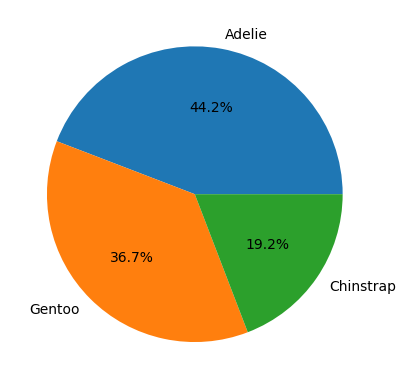

In [ ]:
fig, axs = plt.subplots()
axs.pie(train['species'].value_counts(), labels=train['species'].value_counts().index, autopct='%1.1f%%')

plt.show()

##Histograms of Features

We are now going to plot a histograms for the features of the penguins.

We will use matplotlib hist function to plot four histograms - one for each of the four features: 'Bill length', 'Bill depth', 'Flippler length', 'Body mass' which will act as our x axis. The y axis is the count of how many penguins fall into each category. The fig.tight_layout ensures that there is padding between each histogram so that the title are not overlapping in a histogram that was not related to it.

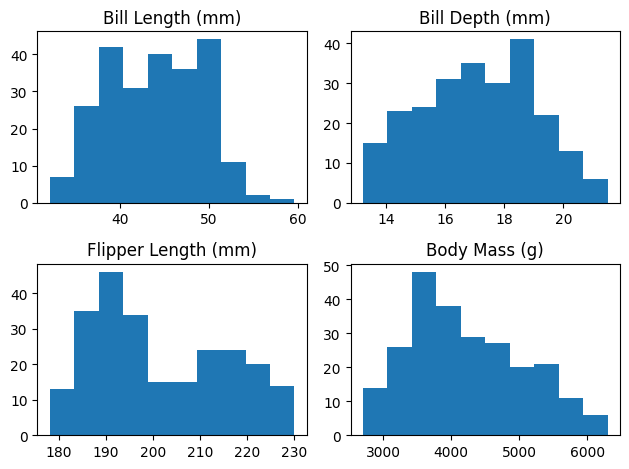

In [ ]:
fig, axs = plt.subplots(2, 2)
n_bins = 10
axs[0,0].hist(train['bill_length_mm'], bins=n_bins)
axs[0,0].set_title('Bill Length (mm)')

axs[0,1].hist(train['bill_depth_mm'], bins=n_bins)
axs[0,1].set_title('Bill Depth (mm)')

axs[1,0].hist(train['flipper_length_mm'], bins=n_bins)
axs[1,0].set_title('Flipper Length (mm)')

axs[1,1].hist(train['body_mass_g'], bins=n_bins)
axs[1,1].set_title('Body Mass (g)')

fig.tight_layout()

##Box Plots of Features

Intrepreting a box plot was sometihng I have not done before, and so I went through both matplotlib and seaborn documentation for information as we are using their libraries.

From the matplotlib documentation, a boxplot give the following. A box is displayed that extends from the first quartile (Q1) to the third quartile (Q3) which represents 25%-75% of the data. A line is drawn in the box to show the median of the data.

The lines that extend from the box are called whiskers, these represent the furthest data points within 1.5x of the inter-quartile range (IRQ) which is the difference of Q3 and Q1. To calculate the top whisker you add Q3 to the IRQ and for the bottom whisker you take away Q1 from the IRQ.

Any data points that are outside of the whiskers are considered outliers and they are usually represented by dots.

For example take this screenshot below:



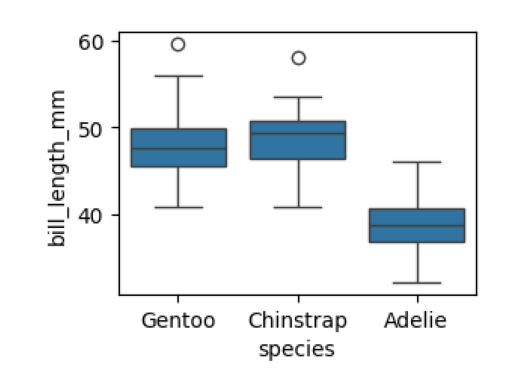

In [ ]:
img_path = '/content/drive/MyDrive/Colab Notebooks/MLWithPython/BoxPlotImage.png'

img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()


Focusing on the Gentoo species box plot, we can see that the Q1 is approximately 46 bill length and the Q3 is approximately 50 bill length and thus the IRQ would approximately 4. Then to calculate the whiskers the formula would **Q3+1.5xIQR** for the top and the bottom would **Q1-1.5xIQR**. Doing the calculation our top whiskers is 56 and our bottom 40 which matches our diagram, and also we can see that there is an outlier.

Here we are now using the seaborn function to make four boxplots for the bill length, depth, flipper length, and body mass for each species of penguins.

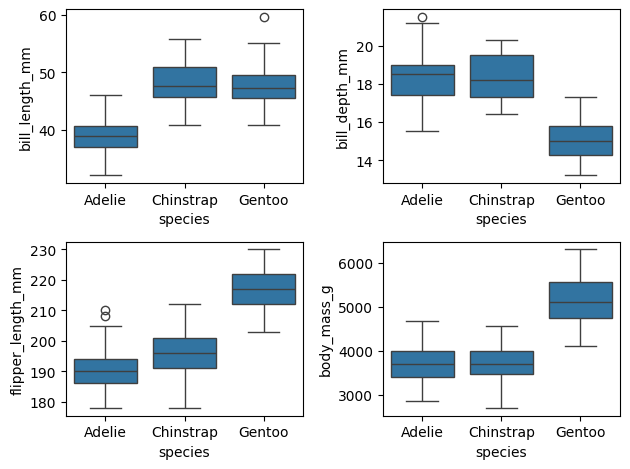

In [ ]:
fig, axs = plt.subplots(2, 2)
sns.boxplot(x='species', y='bill_length_mm', data=train, ax=axs[0,0]);
sns.boxplot(x='species', y='bill_depth_mm', data=train, ax=axs[0,1]);
sns.boxplot(x='species', y='flipper_length_mm', data=train, ax=axs[1,0]);
sns.boxplot(x='species', y='body_mass_g', data=train, ax=axs[1,1]);

fig.tight_layout()

Some information to take note from this box plots is that the Gentoo species has the biggest flipper length and body mass out of the three species and that the Chinstrap species has the longest bill length, while the Adelie speices has the longest bill depth.

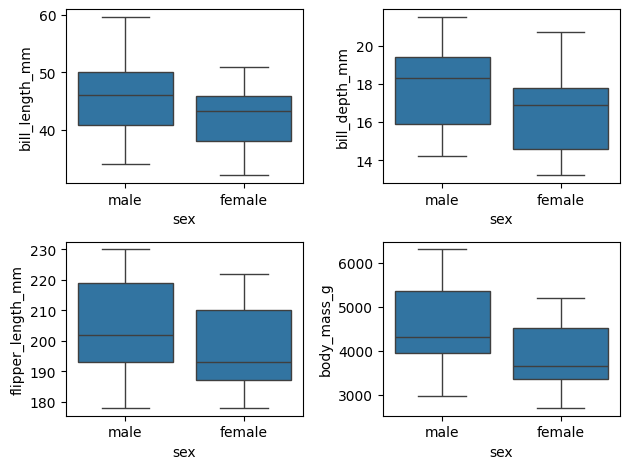

In [ ]:
fig, axs = plt.subplots(2, 2)
sns.boxplot(x='sex', y='bill_length_mm', data=train, ax=axs[0,0]);
sns.boxplot(x='sex', y='bill_depth_mm', data=train, ax=axs[0,1]);
sns.boxplot(x='sex', y='flipper_length_mm', data=train, ax=axs[1,0]);
sns.boxplot(x='sex', y='body_mass_g', data=train, ax=axs[1,1]);

fig.tight_layout()

In this box plot we see that the male sex generally has more occurance of higher values in terms of the female sex.

##Scatter Plot of Features

Here we are going to be using scatter plot to see if there is any relationship between a pair of variables. I have decided to view the relationship of Bill Length vs Bill Depth, Flipper Length vs Body Mass, Bill Length vs Flipper Length, and Bill Depth vs Body Mass.

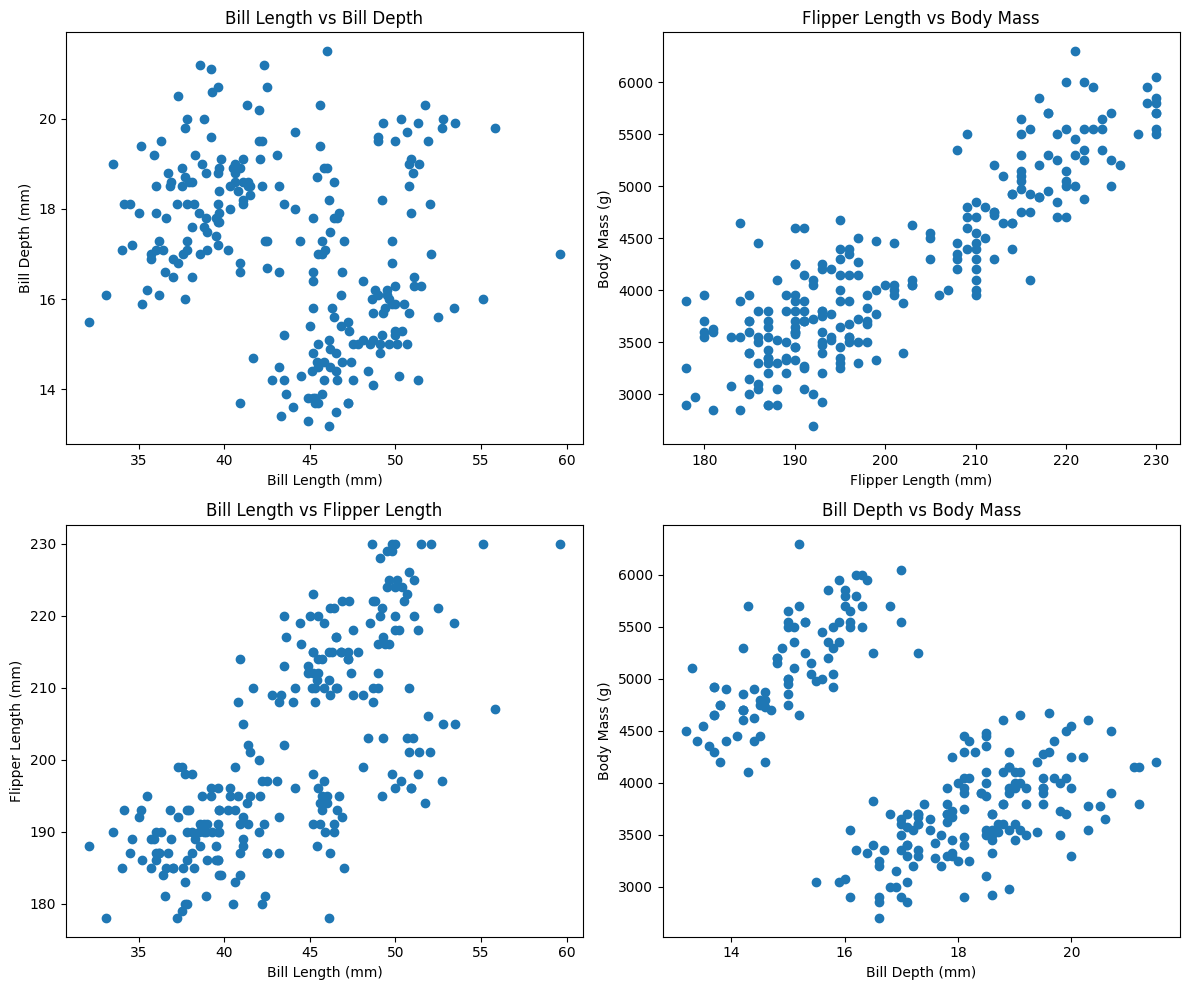

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0,0].scatter(train['bill_length_mm'], train['bill_depth_mm'])
axs[0,0].set_xlabel('Bill Length (mm)')
axs[0,0].set_ylabel('Bill Depth (mm)')
axs[0,0].set_title('Bill Length vs Bill Depth')

axs[0,1].scatter(train['flipper_length_mm'], train['body_mass_g'])
axs[0,1].set_xlabel('Flipper Length (mm)')
axs[0,1].set_ylabel('Body Mass (g)')
axs[0,1].set_title('Flipper Length vs Body Mass')

axs[1,0].scatter(train['bill_length_mm'], train['flipper_length_mm'])
axs[1,0].set_xlabel('Bill Length (mm)')
axs[1,0].set_ylabel('Flipper Length (mm)')
axs[1,0].set_title('Bill Length vs Flipper Length')

axs[1,1].scatter(train['bill_depth_mm'], train['body_mass_g'])
axs[1,1].set_xlabel('Bill Depth (mm)')
axs[1,1].set_ylabel('Body Mass (g)')
axs[1,1].set_title('Bill Depth vs Body Mass')

fig.tight_layout()
plt.show()

From the scatter plots we can infer that both Flipper Length vs Body Mass and Bill Length vs Flipper Length scatter plots are positive linear correlated, while the Bill Length vs Bill Depth seems to have no correlation. Interestingly the Bill Depth vs Body Mass shows a considerable gap in the scatter plot, where the greater the bill depth, the lower the penguins body mass tends to be.




##Calculate & Visualise Correlations

We are going to use the Pandas corr function to compute the correlation matrix between the columns.

I am going to be using our training data set we extracted.

In [ ]:
numeric_train = train.drop(['species', 'island', 'sex'], axis=1)
numeric_train.corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
bill_length_mm,1.000000,-0.260868,0.709430,0.642181,0.040959
bill_depth_mm,-0.260868,1.000000,-0.580681,-0.471891,-0.070906
flipper_length_mm,0.709430,-0.580681,1.000000,0.873222,0.160422
body_mass_g,0.642181,-0.471891,0.873222,1.000000,0.011001
year,0.040959,-0.070906,0.160422,0.011001,1.000000


Intially I run the command of train.corr(), this led to an error where it could not convert a string to a float. This is because in our dataframe we have non-numeric values such as 'species', 'island', and 'sex', which is the reason the error is happening. The pandas method of corr() can only be used on numeric columns.

To fix this we can either decided to drop the columns that were non-numeric or convert them into numeric values.

After the intial command code failed, Gemini suggested the above command, it use the train.drop method to leave out the non-numeric values from our dataframe before it calculates the correlation.

With our numeric dataframe, we can now use the Seaborn heatmap function to visualise the correlations matrix.

<Axes: >

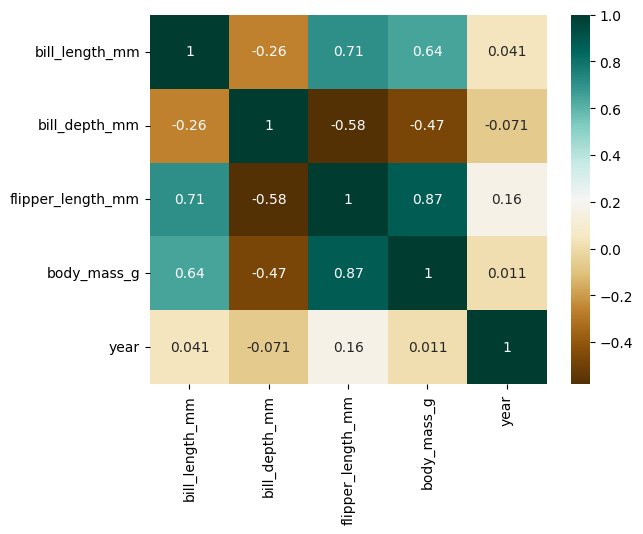

In [ ]:
corr_matrix = numeric_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap="BrBG")

A correlation matrix is used to show two pairs of variables are related to each other. Each square contains a value between -1 or 1.

To intrepret this correlation matrix, take for example the correlation between flipper_length_mm and body_mass_g is in the postive (0.87), which can indicate that they're postively correlated. The longer the flipper length, the higher the penguin's body mass tends to be.

Another example, this time a negatively correlated one. The correlation between bill_depth_mm and bill_length_mm is in the negative (-0.26), suggesting that penguins with deeper bills tends to have shorter bill length and vice versa.

# A Decision Tree Classifier ML Model

A classifier is a machine learning model used to discriminate different object based on certain features.

##Extract the Data into x and y Arrays.

We are going to be extracting our training and testing data into x and y arrays. The target, y, is the species. The bill length, depth, flippler length, and body mass are inputs, x.

In [ ]:
x_train = train[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y_train = train.species
x_test = test[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y_test = test.species

The x_train is getting the four columns is listed in the square brackets from the train dataset, while the y_train get the species column. This is the same for the x_test and y_test.

##Create & Fit the Decision Tree Classifer

For our decision tree classifer we wil be importing sklearn libraries [8].

In [ ]:
from sklearn import tree
from sklearn import metrics

Create the decision tree model, then fit the training data to the model.

In [ ]:
clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=1)
clf = clf.fit(x_train, y_train)

For our decision tree model, we have a criteria of entropy wihch is used to measure a quality of the split. The random state is set to 1, this is to ensure we get the same result if we run the code again.

# Model Test & Evaluation

In [ ]:
y_pred = clf.predict(x_test)

Here we are using our decision tree model to make predictions on pengunis species based on the test data we gave it, this prediction will then be used later for our confusion matrix to see if our model predict it correctly.

#Visualise the Decision Tree Classifer

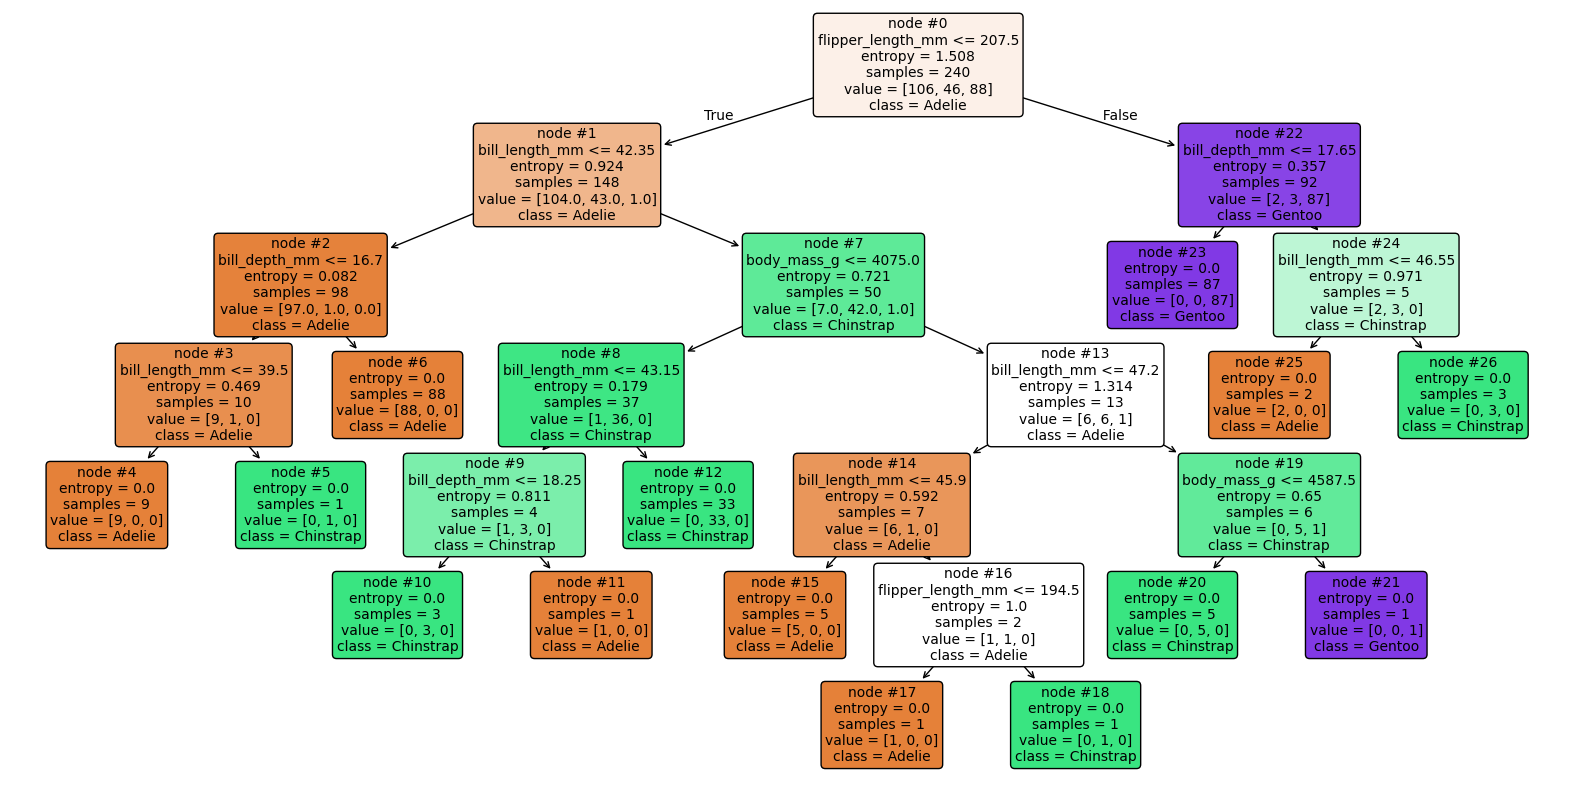

In [ ]:
fig, ax = plt.subplots(1, 1 ,figsize=(20,10))
fn = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cn = ['Adelie', 'Chinstrap', 'Gentoo']
artists = tree.plot_tree(clf, feature_names=fn, class_names=cn, filled=True, node_ids=True, label='all', impurity=True, fontsize=10, rounded=True);

**Intrepreting our Decision Tree**

For each node it contains the following:

At the top of any node that is not a leaf mode, there will be a rule. This rule will be based on one of the features and a certain threshold value. If the condition is true, you follow the left branch, and if it false, you follow the right branch.

Next is the entropy. The higher the number, the more species that are mixed togther in that specific node, while a lower entropy or a zero entropy score means no species are mixed at all.

The sample tells us how many penguins from the training set reached that specific node.

Value shows the distrubtion of the different species of penguins in the node. The three numbers corressponds to the species of penguins which goes in the order of ['Adelie', 'Chinstrap', 'Gentoo']. For example, value = [100, 0, 0] means there are 100 Adelie penguins, 0 Chinstrap and 0 Gentoo in that node.

Finally, the class will display the species that the majority of samples in that node belongs to.

#Plot the Confusion Matrix

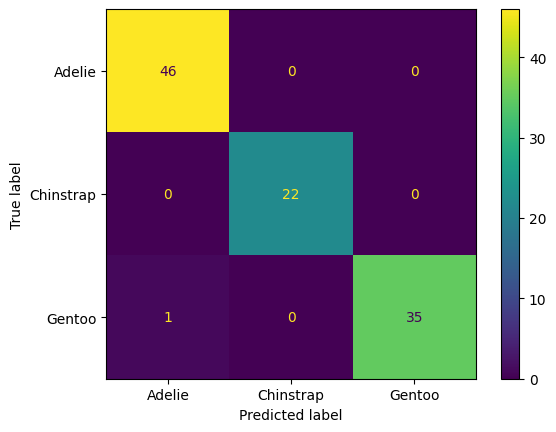

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

A confusion matrix is a table used to measure how well our model is performing, by comparing the prediction our model has made with the actual answer. The y_pred variable is using our x_test arrays to predict the species of penguins and then compares it with our y_test.

For example in one run I did, in one confusion matrix. Our confusion matrix predicted 35 Gentoo penguins correctly, but 1 was predicted to be an Adelie but was in fact a Gentoo.

An ideal confusion matrix would be to have all the numbers along the left diagonal, any numbers not on the left diagonal means that our prediction model made an incorrect prediction.

#References

[1] A. Horst, "palmerpenguins," 2022. [Online]. Available: https://github.com/allisonhorst/palmerpenguins. [Accessed 15 11 2023].

[2] Wikipedia, "Decision Tree," [Online]. Available: https://en.wikipedia.org/wiki/Decision_tree. [Accessed 15 11 2023].

[3] V. Maini. (2017, Aug 19). *Machine Learning for Humans* [online]. Available: https://medium.com/machine-learning-for-humans/why-machine-learning-matters-6164faf1df12.

[4] M. Lynch, “Machine Learning with Python”, Lecture, ATU, Galway, 2023.

[5] pandas, "pandas documentation," [Online]. Available: https://pandas.pydata.org/pandas-docs/stable/index.html [Accessed 21 10 2025]

[6] Matplotlib, "Matplotlib: Visualization with Python," [Online]. Available: https://matplotlib.org/ [Accessed 21 10 2025]

[7] seaborn, "seaborn: statistical data visualization," [Online]. Available: https://seaborn.pydata.org/ [Accessed 21 10 2025]

[8] scikit-learn, "scikit-learn Machine Learning in Python," [Online]. Available: https://scikit-learn.org/stable/index.html [Accessed 04 11 2025]

[9] Gemini, private communication, November, 2025.  